# First Classification Step

Here I will perform the classification using the image embeddings using both SigLIP and CLIP embeddings with the complete image dataset we have available. 

This will work as baseline comparison to the performance when applying the filtering using CLEANLAB. 

Expected results:
+ The performance to be affected by the quality of the data. 
+ Performance flats out and underperforms compared to Sigurðardóttir et al. 2023


This notebook includes for CLIP and SigLIP2 extracted features: 

* Preprocessing: feature engineering and augmentation (include quarter and length), train/test split and scaling
* Train and Testing: Train 10 models on increasingly more data (10% steps). Then evaluates the performance on the test set. Each of the models trained on 100% of the training data is saved in their respective folder with the filename convention: {model}_seed{seed_nr}_baseline.joblib
* Learning Curves: Plot learning Curves to see how the model behaves when there is increasingly more data available. 

In [39]:
import numpy as np 
import pandas as pd 
import os
import matplotlib.pyplot as plt 
from PIL import Image
from src.features import augment_embeddings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import joblib
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import json 



In [40]:
df = pd.read_csv("../../cod_otolith_age_final_with_scale.csv")
df[["length", "month_sin", "month_cos", "shot_latitude", "shot_longitude", "is_survey", "seg_width_px", "seg_height_px", "seg_aspect_ratio"]]
df

,measurement_id,sample_id_x,station_id,cruise_id,sampleType_number,age,length,weight,sex_number,maturity_number,...,seg_width_px_x,seg_height_px_x,seg_width_px_y,seg_height_px_y,seg_width_px,seg_height_px,seg_aspect_ratio,month_sin,month_cos,is_survey
0,21514156,507573,322736,18797,34,14.0,108,9550.0,1.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.660254e-01,-5.000000e-01,False
1,23625439,542618,340495,20498,1,6.0,69,NaN,1.0,4.0,...,840.0,304.0,840.0,304.0,840.0,304.0,255.360,1.224647e-16,-1.000000e+00,False
2,23625441,542618,340495,20498,1,7.0,66,NaN,2.0,1.0,...,761.0,330.0,761.0,330.0,761.0,330.0,251.130,1.224647e-16,-1.000000e+00,False
3,23625442,542618,340495,20498,1,7.0,72,NaN,1.0,3.0,...,780.0,389.0,780.0,389.0,780.0,389.0,303.420,1.224647e-16,-1.000000e+00,False
4,23625445,542618,340495,20498,1,5.0,65,NaN,2.0,1.0,...,747.0,314.0,747.0,314.0,747.0,314.0,234.558,1.224647e-16,-1.000000e+00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8659,24785922,555106,348573,20745,30,6.0,83,4535.9,2.0,52.0,...,869.0,463.0,869.0,463.0,869.0,463.0,402.347,1.000000e+00,6.123234e-17,True
8660,24785923,555106,348573,20745,30,5.0,61,2033.9,2.0,2.0,...,743.0,288.0,743.0,288.0,743.0,288.0,213.984,1.000000e+00,6.123234e-17,True
8661,24785995,555106,348573,20745,30,4.0,42,575.0,1.0,1.0,...,553.0,235.0,553.0,235.0,553.0,235.0,129.955,1.000000e+00,6.123234e-17,True
8662,24786305,555107,348574,20745,30,2.0,24,109.0,1.0,1.0,...,407.0,147.0,407.0,147.0,407.0,147.0,59.829,1.000000e+00,6.123234e-17,True


## CLIP

### Preprocessing

In [41]:

# Load data 
data = np.load("../../outputs/segmented_embeddings/siglip2-so400m-14-384_clahe_embeddings.npz")
features, measurements_ids, labels = data["features"], data["measurement_ids"], data["labels"]

# Selecting metadata to include in feature vector
columns = ["length", "month_sin", "month_cos", "shot_latitude", "shot_longitude", "is_survey", "seg_width_px", "seg_height_px", "seg_aspect_ratio"]
metadata_csv = "../../cod_otolith_age_final_with_scale.csv"

features = augment_embeddings(      # Augments the feature vectors with the metadata quarters and fish length
                features, measurements_ids, metadata_csv, columns
            )


rs = 77 # Random State 


# Train/Test split
## Will use CV therefore no validation split

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, stratify=labels, random_state = rs)

print(f"Train set dimension: {len(X_train)}")
print(f"Test set dimension: {len(X_test)}")

print("="*60)
print("SCALING FEATURES")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original feature shape: {X_train.shape}")
print(f"Scaled feature shape: {X_train_scaled.shape}")
print(f"Scaler fit on {X_train.shape[0]} samples")


alphas = np.logspace(1.5, 3, 50)
print(f"Alphas range: {round(alphas.min(), 2)} to {alphas.max()}")

Train set dimension: 7326
Test set dimension: 1293
SCALING FEATURES
Original feature shape: (7326, 1161)
Scaled feature shape: (7326, 1161)
Scaler fit on 7326 samples
Alphas range: 31.62 to 1000.0


### Train and Testing

In [42]:
import random

random.seed(42)

# Set seeds
seeds = random.sample(range(1, 101), 10)
print(f"Seeds used: {seeds}")

# Set train props
train_props = [0.1, 0.2, 0.3, 0.4, .5, .6, .7, .8, .9, 1.]

# Set variables
performance = {seed: {} for seed in seeds}
alphas = np.logspace(1.5, 3, 50)

for seed in tqdm(seeds): 
    
    performance[seed] = {}

    X_train, X_test, y_train, y_test = train_test_split(
        features, 
        labels, 
        test_size=0.15, 
        stratify=labels, 
        random_state = seed
        )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(X_train.shape)
    
    for prop in train_props:
        #X_train
        n_samples = int(prop * X_train.shape[0])
        X_train_scaled_sl, y_train_sl = X_train_scaled[:n_samples,:], y_train[:n_samples]

        ridge = RidgeCV(alphas=alphas, cv=5) 
        ridge.fit(X_train_scaled_sl, y_train_sl)

        # ========== PREDICTIONS ==========

        y_test_pred = ridge.predict(X_test_scaled)
        y_test_pred_class = np.clip(np.round(y_test_pred).astype(int), 1, 10)
        # Accuracy
        acc_test = accuracy_score(y_test, y_test_pred_class)

        performance[seed][prop] = {
            "accuracy": acc_test,
            "n_samples": n_samples,
            "best_alpha": ridge.alpha_
        }
        if prop == 1.0: 
            model_name = f"models/CLIP-ViT-L-14/CLIP_seed{seed}_baseline.joblib"
            joblib.dump(ridge, model_name)

Seeds used: [82, 15, 4, 95, 36, 32, 29, 18, 14, 87]


  0%|          | 0/10 [00:00<?, ?it/s]

(7326, 1161)


  0%|          | 0/10 [00:28<?, ?it/s]


KeyboardInterrupt: 

In [ ]:


with open("CLIP-performance-pre-cleanlab.json", "w") as f:
    json.dump(performance, f, indent = 4)


NameError: name 'performance' is not defined

In [6]:
with open("CLIP-performance-pre-cleanlab.json", "r") as f:
    performance = json.load(f)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

### Plot Learning Curve

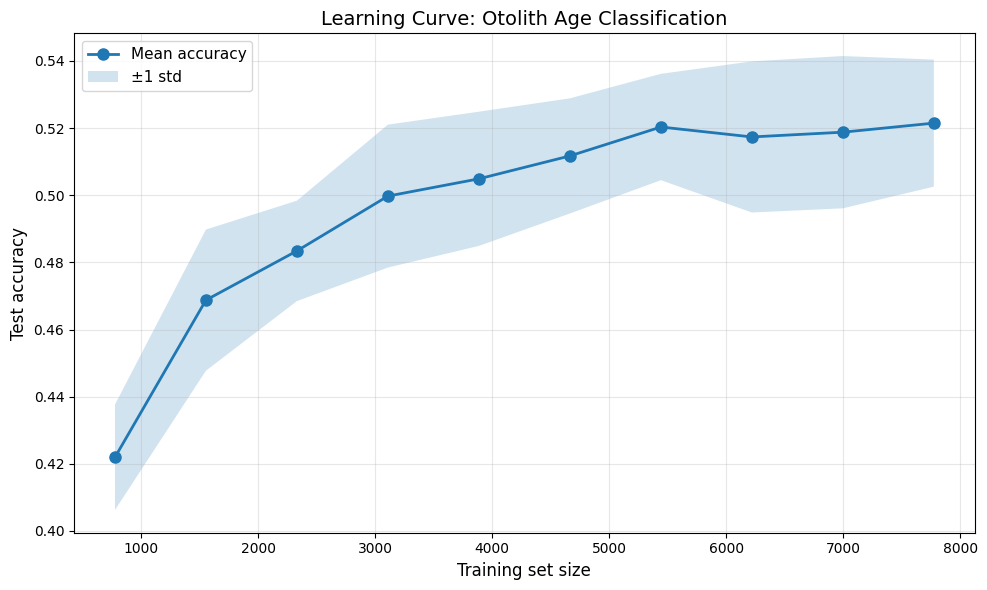

Training Size | Mean Accuracy | Std Dev
---------------------------------------------
          777 |        0.4219 |  0.0157
         1554 |        0.4688 |  0.0210
         2331 |        0.4834 |  0.0150
         3109 |        0.4997 |  0.0213
         3886 |        0.5049 |  0.0200
         4663 |        0.5117 |  0.0172
         5441 |        0.5203 |  0.0158
         6218 |        0.5174 |  0.0225
         6995 |        0.5188 |  0.0227
         7773 |        0.5215 |  0.0189


In [9]:
# Load performances of the clip model
with open("CLIP-performance-pre-cleanlab.json", "r") as f: 
    performance = json.load(f)

# Extract metadata into arrays
seeds = [i for i in performance]
train_props = [prop for prop in performance[seeds[0]]]

# Collect accuraciees for each proportion 
accuracies_by_prop = {prop: [] for prop in train_props}

for seed in seeds:
    for prop in train_props: 
        acc = performance[seed][prop]["accuracy"]
        accuracies_by_prop[prop].append(acc)


average_std = []
average_perf = []

# Calculate training length
train_dim = [int(float(p) * X_train.shape[0]) for p in list(accuracies_by_prop.keys())]


# Calculate mean and std for each proportion
average_perf_clip = [np.mean(accuracies_by_prop[d]) for d in accuracies_by_prop]
average_std_clip = [np.std(accuracies_by_prop[d]) for d in accuracies_by_prop]



# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_dim, average_perf_clip, 'o-', linewidth=2, markersize=8, label='Mean accuracy')
plt.fill_between(train_dim, 
                 np.array(average_perf_clip) - np.array(average_std_clip),
                 np.array(average_perf_clip) + np.array(average_std_clip),
                 alpha=0.2, label='±1 std')

plt.xlabel('Training set size', fontsize=12)
plt.ylabel('Test accuracy', fontsize=12)
plt.title('Learning Curve: Otolith Age Classification', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print summary
print("Training Size | Mean Accuracy | Std Dev")
print("-" * 45)
for prop, n_samples in zip(train_props, train_dim):
    mean = np.mean(accuracies_by_prop[prop])
    std = np.std(accuracies_by_prop[prop])
    print(f"{n_samples:>13} | {mean:>13.4f} | {std:>7.4f}")


## SigLIP

### PreProcessing

In [28]:
# Load data 
data = np.load("../../outputs/segmented_embeddings/siglip2-so400m-14-384_clahe_embeddings.npz")
features, measurements_ids, labels = data["features"], data["measurement_ids"], data["labels"]

# Selecting metadata to include in feature vector
columns = ["length", "month_sin", "month_cos", "shot_latitude", "shot_longitude", "is_survey", "seg_width_px", "seg_height_px", "seg_aspect_ratio"]
metadata_csv = "../../cod_otolith_age_final_with_scale.csv"

features = augment_embeddings(      # Augments the feature vectors with the metadata quarters and fish length
                features, measurements_ids, metadata_csv, columns
            )


rs = 77 # Random State 


# Train/Test split
## Will use CV therefore no validation split

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.15, stratify=labels, random_state = rs)

print(f"Train set dimension: {len(X_train)}")
print(f"Test set dimension: {len(X_test)}")

print("="*60)
print("SCALING FEATURES")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original feature shape: {X_train.shape}")
print(f"Scaled feature shape: {X_train_scaled.shape}")
print(f"Scaler fit on {X_train.shape[0]} samples")


alphas = np.logspace(1.5, 3, 20)
print(f"Alphas range: {round(alphas.min(), 2)} to {alphas.max()}")

Train set dimension: 7326
Test set dimension: 1293
SCALING FEATURES
Original feature shape: (7326, 1161)
Scaled feature shape: (7326, 1161)
Scaler fit on 7326 samples
Alphas range: 31.62 to 1000.0


### Train and Testing

In [29]:
import random

random.seed(42)

# Set seeds
seeds = random.sample(range(1, 101), 10)
print(f"Seeds used: {seeds}")

# Set train props
train_props = [0.1, .2, .3, .4, .5, .6, .7, .8, .9, 1.]

# Set variables
performance = {seed: {} for seed in seeds}
alphas = np.logspace(1.5, 3, 30)

for seed in tqdm(seeds): 
    
    performance[seed] = {}

    X_train, X_test, y_train, y_test = train_test_split(
        features, 
        labels, 
        test_size=0.1, 
        stratify=labels, 
        random_state = seed
        )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(X_train.shape)
    
    for prop in tqdm(train_props):
        #X_train
        n_samples = int(prop * X_train.shape[0])
        X_train_scaled_sl, y_train_sl = X_train_scaled[:n_samples,:], y_train[:n_samples]

        ridge = RidgeCV(alphas=alphas, cv=5) 
        ridge.fit(X_train_scaled_sl, y_train_sl)

        # ========== PREDICTIONS ==========

        y_test_pred = ridge.predict(X_test_scaled)
        y_test_pred_class = np.clip(np.round(y_test_pred).astype(int), 1, 10)
        # Accuracy
        acc_test = accuracy_score(y_test, y_test_pred_class)

        performance[seed][prop] = {
            "accuracy": acc_test,
            "n_samples": n_samples,
            "best_alpha": ridge.alpha_
        }
        if prop == 1.0: 
            model_name = f"models/SigLIP2-so400m-14-384-segmented/SigLIP2_seed{seed}_baseline.joblib"
            joblib.dump(ridge, model_name)

Seeds used: [82, 15, 4, 95, 36, 32, 29, 18, 14, 87]


  0%|          | 0/10 [00:00<?, ?it/s]

(7757, 1161)


 10%|█         | 1/10 [12:17<1:50:33, 737.04s/it]

(7757, 1161)


...

 80%|████████  | 8/10 [1:34:19<23:25, 702.78s/it]

(7757, 1161)


 90%|█████████ | 9/10 [1:45:52<11:39, 699.78s/it]

(7757, 1161)


100%|██████████| 10/10 [1:57:34<00:00, 705.46s/it]


In [30]:
import json 

with open("SigLIP2-segmented-performance-ore-cleanlab.json", "w") as f:
    json.dump(performance, f, indent = 4)

### Plot Learning Curve

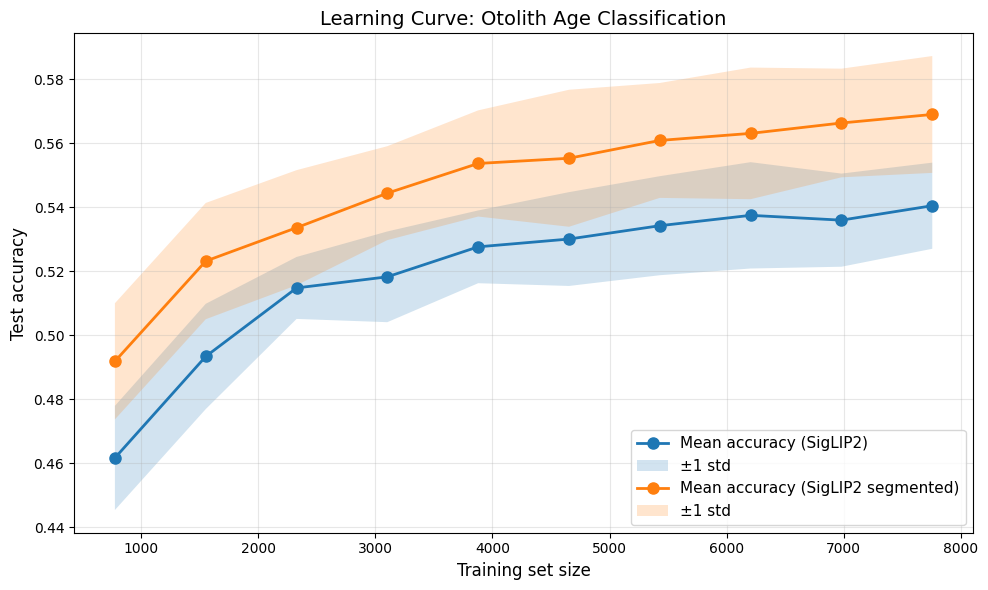

Training Size | Mean Accuracy | Std Dev
---------------------------------------------
          775 |        0.4617 |  0.0163
         1551 |        0.4934 |  0.0165
         2327 |        0.5148 |  0.0097
         3102 |        0.5183 |  0.0142
         3878 |        0.5277 |  0.0114
         4654 |        0.5301 |  0.0147
         5429 |        0.5343 |  0.0155
         6205 |        0.5375 |  0.0166
         6981 |        0.5360 |  0.0146
         7757 |        0.5405 |  0.0135


In [36]:
# Load performances of the clip model
with open("SigLIP2-segmented-performance-ore-cleanlab.json", "r") as f: 
    performance_seg = json.load(f)

with open("SigLIP2-clahe-repeat-performance-pre-cleanlab.json") as f: 
    performance = json.load(f)
    
# Extract metadata into arrays
seeds = [i for i in performance]
train_props = [prop for prop in performance[seeds[0]]]

# Collect accuracies for each proportion 
accuracies_by_prop = {prop: [] for prop in train_props}
accuracies_by_prop_seg = {prop: [] for prop in train_props}  # Fix 1: proper init, not shallow copy

for seed in seeds:
    for prop in train_props: 
        acc = performance[seed][prop]["accuracy"]
        acc_seg = performance_seg[seed][prop]["accuracy"]
        accuracies_by_prop[prop].append(acc)
        accuracies_by_prop_seg[prop].append(acc_seg)

# Calculate training length
train_dim = [int(float(p) * X_train.shape[0]) for p in list(accuracies_by_prop.keys())]

# Calculate mean and std for each proportion
average_perf_siglip = [np.mean(accuracies_by_prop[d]) for d in accuracies_by_prop]
average_std_siglip = [np.std(accuracies_by_prop[d]) for d in accuracies_by_prop]

average_perf_siglip_seg = [np.mean(accuracies_by_prop_seg[d]) for d in accuracies_by_prop_seg]  # Fix 2: correct dict
average_std_siglip_seg = [np.std(accuracies_by_prop_seg[d]) for d in accuracies_by_prop_seg]    # Fix 2: correct dict

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_dim, average_perf_siglip, 'o-', linewidth=2, markersize=8, label='Mean accuracy (SigLIP2)')
plt.fill_between(train_dim, 
                 np.array(average_perf_siglip) - np.array(average_std_siglip),
                 np.array(average_perf_siglip) + np.array(average_std_siglip),
                 alpha=0.2, label='±1 std')

plt.plot(train_dim, average_perf_siglip_seg, 'o-', linewidth=2, markersize=8, label='Mean accuracy (SigLIP2 segmented)')
plt.fill_between(train_dim, 
                 np.array(average_perf_siglip_seg) - np.array(average_std_siglip_seg),
                 np.array(average_perf_siglip_seg) + np.array(average_std_siglip_seg),
                 alpha=0.2, label='±1 std')

plt.xlabel('Training set size', fontsize=12)
plt.ylabel('Test accuracy', fontsize=12)
plt.title('Learning Curve: Otolith Age Classification', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print summary
print("Training Size | Mean Accuracy | Std Dev")
print("-" * 45)
for prop, n_samples in zip(train_props, train_dim):
    mean = np.mean(accuracies_by_prop[prop])
    std = np.std(accuracies_by_prop[prop])
    print(f"{n_samples:>13} | {mean:>13.4f} | {std:>7.4f}")